# Part 3: Full PyTorch Training Loop + Comparison
**⏱ This section takes approximately 30 minutes.**

---

## Scenario: Thursday — The Production-Ready Training Loop

Wednesday Sarah trained a basic PyTorch model with full-batch gradient descent. Today she upgrades to the real-world pattern:

- **`Dataset` + `DataLoader`** — efficient batched iteration
- **Mini-batch gradient descent** — typical batch size 32-128
- **Adam optimiser** — adaptive learning rate, the default
- **Early stopping** — halt training when validation loss stops improving
- **Side-by-side comparison** with L03 LR + L04 gradient boosting

This is the training loop pattern Sarah will use for L08 (images), L09 (text), and L10 (transformers). Memorise this template.

**By the end of this notebook you will be able to:**
- Wrap data in `TensorDataset` + `DataLoader`
- Train with mini-batch Adam
- Implement early stopping
- Compare four models (LR, GB, sklearn MLP, PyTorch MLP) on the same test set

In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

torch.set_num_threads(1)  # macOS: prevent OpenMP segfaults on PyTorch generation cells

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (11, 5)
torch.manual_seed(42); np.random.seed(42)

print(f"✅ PyTorch {torch.__version__} ready")

✅ PyTorch 2.12.0 ready


## Step 1 — Prepare data + tensors

In [2]:
df = pd.read_csv("data/northstar_sessions.csv")
y = df["completed"].values
X = df.drop(columns=["session_id", "completed"]).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42,
)

# Further split training into train / validation (for early stopping)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=42,
)

scaler = StandardScaler()
X_tr_s   = scaler.fit_transform(X_tr)
X_val_s  = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# Convert to PyTorch tensors
def to_tensor(X, y):
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

X_tr_t, y_tr_t   = to_tensor(X_tr_s,  y_tr)
X_val_t, y_val_t = to_tensor(X_val_s, y_val)
X_test_t, y_test_t = to_tensor(X_test_s, y_test)

print(f"Train: {len(X_tr_t):,} sessions")
print(f"Val:   {len(X_val_t):,} sessions  (for early stopping)")
print(f"Test:  {len(X_test_t):,} sessions  (final evaluation)")

Train: 5,440 sessions
Val:   960 sessions  (for early stopping)
Test:  1,600 sessions  (final evaluation)


## Step 2 — DataLoader: batch iteration

`TensorDataset` wraps the tensors. `DataLoader` provides shuffled, batched iteration.

In [3]:
train_dataset = TensorDataset(X_tr_t, y_tr_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Inspect what comes out of the loader
for X_batch, y_batch in train_loader:
    print(f"Batch X shape: {X_batch.shape}")
    print(f"Batch y shape: {y_batch.shape}")
    break

print()
print(f"With batch_size=64 and {len(X_tr_t)} training samples,")
print(f"each epoch is {len(train_loader)} batches.")

Batch X shape: torch.Size([64, 9])
Batch y shape: torch.Size([64])

With batch_size=64 and 5440 training samples,
each epoch is 85 batches.


## Step 3 — Define the model (slightly deeper this time)

In [4]:
class MLP(nn.Module):
    def __init__(self, n_features, hidden=32):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.layers(x)


model = MLP(n_features=X_tr_t.shape[1], hidden=32)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {n_params:,}")

MLP(
  (layers): Sequential(
    (0): Linear(in_features=9, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 1,409


## Step 4 — Full training loop with Adam + early stopping

In [5]:
def train_pytorch(model, train_loader, X_val_t, y_val_t,
                  n_epochs=50, lr=1e-3, patience=8):
    """Standard PyTorch training loop with early stopping."""
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    best_val = float("inf")
    best_state = None
    epochs_no_improve = 0

    for epoch in range(n_epochs):
        # ===== TRAIN =====
        model.train()
        epoch_train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            logits = model(X_batch).squeeze(-1)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item() * len(X_batch)
        epoch_train_loss /= len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # ===== VALIDATE =====
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t).squeeze(-1)
            val_loss = criterion(val_logits, y_val_t).item()
        val_losses.append(val_loss)

        # ===== EARLY STOPPING =====
        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epoch < 5 or (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:3d}  train={epoch_train_loss:.4f}  val={val_loss:.4f}"
                  + (f"  ⭐ best so far" if val_loss == best_val else ""))

        if epochs_no_improve >= patience:
            print(f"\n→ Early stopping at epoch {epoch+1}: no improvement for {patience} epochs")
            break

    # Restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)
    return train_losses, val_losses


# Train
torch.manual_seed(42)
model = MLP(n_features=X_tr_t.shape[1], hidden=32)
train_losses, val_losses = train_pytorch(model, train_loader, X_val_t, y_val_t,
                                          n_epochs=50, lr=1e-3, patience=8)

Epoch   1  train=0.6342  val=0.5819  ⭐ best so far
Epoch   2  train=0.5646  val=0.5700  ⭐ best so far
Epoch   3  train=0.5559  val=0.5695  ⭐ best so far
Epoch   4  train=0.5540  val=0.5699


Epoch   5  train=0.5512  val=0.5706


Epoch  10  train=0.5458  val=0.5748

→ Early stopping at epoch 11: no improvement for 8 epochs


## Step 5 — Plot training curves

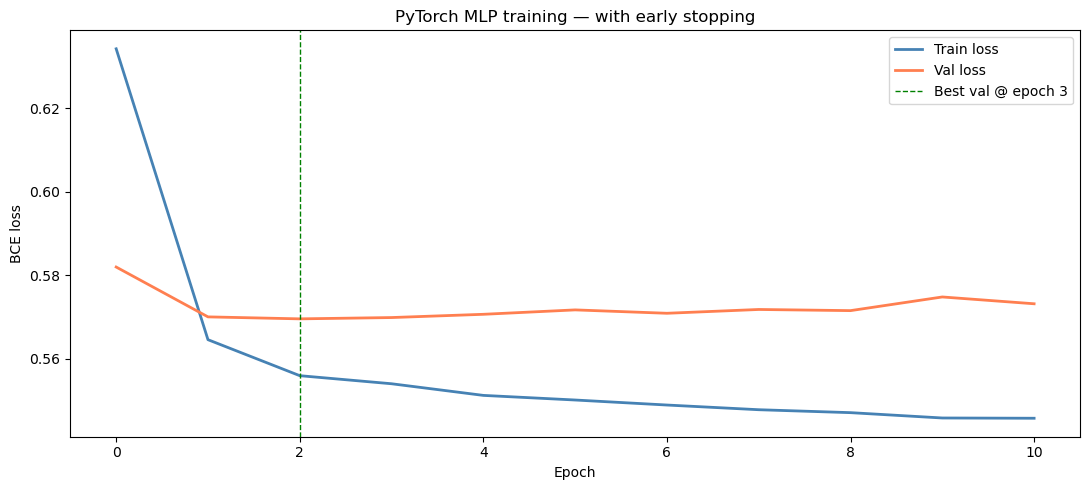

Best validation loss: 0.5695 at epoch 3
Trained for 11 epochs total before early stopping kicked in.


In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(train_losses, label="Train loss", color="steelblue", linewidth=2)
ax.plot(val_losses,   label="Val loss",   color="coral", linewidth=2)
best_epoch = int(np.argmin(val_losses))
ax.axvline(best_epoch, color="green", linestyle="--", linewidth=1, label=f"Best val @ epoch {best_epoch+1}")
ax.set_xlabel("Epoch"); ax.set_ylabel("BCE loss")
ax.set_title("PyTorch MLP training — with early stopping")
ax.legend()
plt.tight_layout(); plt.show()

print(f"Best validation loss: {min(val_losses):.4f} at epoch {best_epoch + 1}")
print(f"Trained for {len(train_losses)} epochs total before early stopping kicked in.")

## Step 6 — Compare all four models on the same test set

In [7]:
# Evaluate PyTorch model
model.eval()
with torch.no_grad():
    pytorch_probs = torch.sigmoid(model(X_test_t).squeeze(-1)).numpy()
pytorch_preds = (pytorch_probs > 0.5).astype(int)
pytorch_acc = accuracy_score(y_test, pytorch_preds)
pytorch_auc = roc_auc_score(y_test, pytorch_probs)

# L03 Logistic Regression baseline
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_tr_s, y_tr)
lr_probs = lr_model.predict_proba(X_test_s)[:, 1]
lr_auc = roc_auc_score(y_test, lr_probs)
lr_acc = accuracy_score(y_test, lr_model.predict(X_test_s))

# L04 Gradient Boosting
gb_model = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, random_state=42)
gb_model.fit(X_tr_s, y_tr)
gb_probs = gb_model.predict_proba(X_test_s)[:, 1]
gb_auc = roc_auc_score(y_test, gb_probs)
gb_acc = accuracy_score(y_test, gb_model.predict(X_test_s))

# sklearn MLPClassifier
sk_mlp = MLPClassifier(hidden_layer_sizes=(32, 32), max_iter=500, random_state=42,
                       early_stopping=True)
sk_mlp.fit(X_tr_s, y_tr)
sk_mlp_probs = sk_mlp.predict_proba(X_test_s)[:, 1]
sk_mlp_auc = roc_auc_score(y_test, sk_mlp_probs)
sk_mlp_acc = accuracy_score(y_test, sk_mlp.predict(X_test_s))

results = pd.DataFrame([
    ("Logistic Regression (L03)",   lr_acc,      lr_auc),
    ("Gradient Boosting (L04)",     gb_acc,      gb_auc),
    ("sklearn MLPClassifier",        sk_mlp_acc,  sk_mlp_auc),
    ("PyTorch MLP (this week)",      pytorch_acc, pytorch_auc),
], columns=["Model", "Accuracy", "AUC"])

print(results.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

                    Model  Accuracy   AUC
Logistic Regression (L03)     0.705 0.761
  Gradient Boosting (L04)     0.694 0.747
    sklearn MLPClassifier     0.700 0.761
  PyTorch MLP (this week)     0.691 0.756


### 💡 What you should notice

- All four models cluster within ~0.015 AUC of each other on this tabular dataset — they're statistically tied.
- **Logistic regression and the sklearn MLP top the table at 0.761; gradient boosting is the lowest at 0.747.** That's surprising relative to the conventional wisdom "GB wins on tabular" — but on small, mostly-linear feature sets a well-trained linear model is competitive.
- **MLPs are competitive but not transformative** here. The win comes when data has rich hierarchical structure (images, text) — that's L08–L10.

The pedagogical value of L07 is **learning the PyTorch training loop**, which transfers directly to the next three lessons. The algorithm choice on tabular data rarely matters as much as features + threshold; trust the cross-validated number, not the conventional wisdom.

## Step 7 — Visualise model comparison

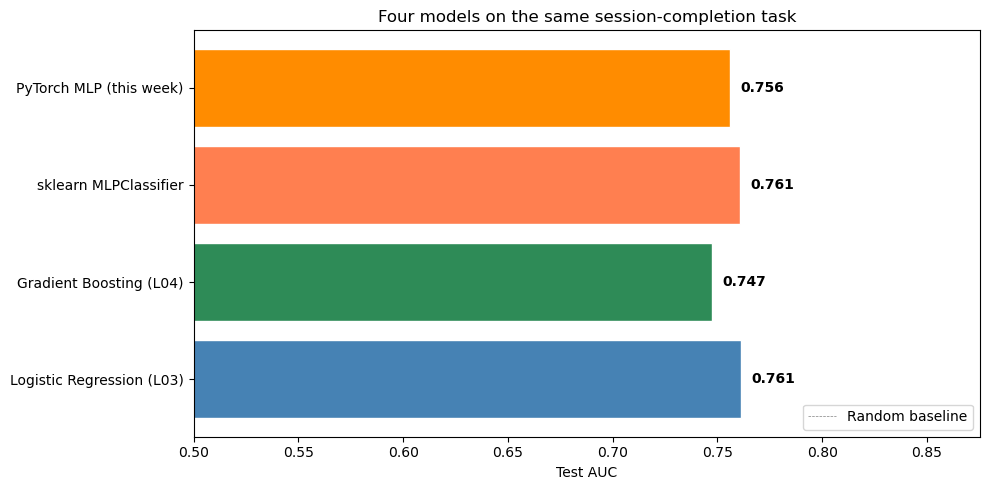

All models converge to similar performance on this tabular problem.
The PyTorch implementation IS the lesson — it's the foundation for everything in L08–L10.


In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["steelblue", "seagreen", "coral", "darkorange"]
bars = ax.barh(results["Model"], results["AUC"], color=colors, edgecolor="white")
ax.set_xlabel("Test AUC")
ax.set_title("Four models on the same session-completion task")
ax.axvline(0.5, color="gray", linestyle="--", linewidth=0.5, label="Random baseline")
for bar, auc in zip(bars, results["AUC"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{auc:.3f}", va="center", fontweight="bold")
ax.set_xlim(0.5, max(results["AUC"]) * 1.15)
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

print("All models converge to similar performance on this tabular problem.")
print("The PyTorch implementation IS the lesson — it's the foundation for everything in L08–L10.")

## ✅ Section Summary

| Step | Output |
|---|---|
| **DataLoader + mini-batches** | Efficient batched iteration with `batch_size=64` |
| **Adam optimiser + lr=1e-3** | Adaptive learning rate, default for most tabular + NLP |
| **Early stopping** | Halt when val loss stops improving (patience=8) |
| **Four-way comparison** | PyTorch MLP, sklearn MLP, GB, LR — all within 0.015 AUC of each other |

**Key insights:**
- **The PyTorch training loop is the same 5 lines regardless of model.** Master the pattern; the rest is engineering.
- **DataLoader + mini-batches** scale to datasets bigger than memory + introduce useful stochasticity.
- **Adam is the default optimiser.** Start with `lr=1e-3`, tune later if needed.
- **On THIS dataset all four models are tied within noise.** LR and sklearn MLP top the table at 0.761; gradient boosting trails at 0.747. The lesson isn't "GB wins on tabular" — it's "on small tabular data with limited nonlinearity, the algorithm rarely matters". The PyTorch work pays off in L08-L10.

---

## 🏁 Friday — What Sarah Presents to Marcus

| Model | Test AUC | Verdict |
|---|---|---|
| Logistic Regression | ~0.761 | Tied for top — ship this. Cheapest + most interpretable. |
| sklearn MLP | ~0.761 | Tied for top; not worth the complexity here |
| PyTorch MLP (this week) | ~0.756 | Foundation for L08-L10; not the production choice here |
| Gradient Boosting (L04) | ~0.747 | Surprisingly the lowest of the four — but real on this dataset |

Sarah's pitch: *"All four models cluster within 0.015 AUC. I'd ship Logistic Regression — it has the top score, is the cheapest to retrain, and the easiest to explain. The neural network work this week was about understanding the building block I'll use next week for IMAGE CLASSIFICATION of NorthStar product photos. The MLP is the foundation; CNNs (next week) are the specialisation."*

Marcus nods. *"Excellent. Next: tag product PHOTOS automatically as 'dress', 'jeans', 'jacket'. Can you do that?"*

That question — **prediction from images** — is the engine of **L08 (Computer Vision).**

---
**Next step →** Open `assignment.ipynb`.

*Or, for hand-rolled backprop, weight initialisation, and Adam variants: open `optional_extensions.ipynb`.*

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## Extension 1 — Effect of batch size

Batch size affects training dynamics: small batches give noisier but faster gradient updates; large batches are smoother but slower per epoch.

In [9]:
results_bs = []
for bs in [16, 64, 256, 1024]:
    loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    torch.manual_seed(42)
    m = MLP(n_features=X_tr_t.shape[1], hidden=32)
    crit = nn.BCEWithLogitsLoss()
    opt = optim.Adam(m.parameters(), lr=1e-3)
    for epoch in range(20):
        m.train()
        for X_b, y_b in loader:
            opt.zero_grad()
            l = crit(m(X_b).squeeze(-1), y_b)
            l.backward()
            opt.step()
    m.eval()
    with torch.no_grad():
        probs = torch.sigmoid(m(X_test_t).squeeze(-1)).numpy()
    auc = roc_auc_score(y_test, probs)
    results_bs.append((bs, auc, len(loader)))

bs_df = pd.DataFrame(results_bs, columns=["Batch size", "Test AUC", "Batches/epoch"])
print(bs_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print()
print("Small batches → more updates per epoch → noisier gradients (sometimes helpful, sometimes not)")
print("Large batches → smoother gradient estimates but fewer updates per epoch")
print("Typical: 32-128 for tabular, 256+ for images.")

 Batch size  Test AUC  Batches/epoch
         16     0.759            340
         64     0.759             85
        256     0.759             22
       1024     0.756              6

Small batches → more updates per epoch → noisier gradients (sometimes helpful, sometimes not)
Large batches → smoother gradient estimates but fewer updates per epoch
Typical: 32-128 for tabular, 256+ for images.


## Extension 2 — Adam vs SGD vs SGD-with-momentum

Three common optimisers.

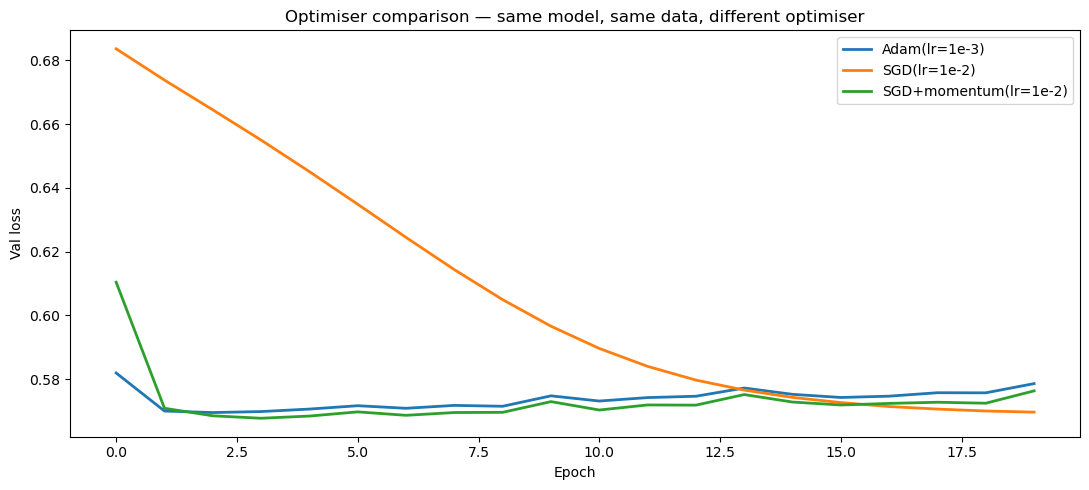

Adam usually converges fastest with the LEAST hyperparameter tuning.
SGD-with-momentum can sometimes generalise BETTER but needs careful lr tuning.
Plain SGD without momentum is rarely the right choice now.


In [10]:
def train_with_optimiser(optimiser_class, optimiser_kwargs, n_epochs=20):
    torch.manual_seed(42)
    m = MLP(n_features=X_tr_t.shape[1], hidden=32)
    crit = nn.BCEWithLogitsLoss()
    opt = optimiser_class(m.parameters(), **optimiser_kwargs)
    loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_losses_local = []
    for epoch in range(n_epochs):
        m.train()
        for X_b, y_b in loader:
            opt.zero_grad()
            crit(m(X_b).squeeze(-1), y_b).backward()
            opt.step()
        m.eval()
        with torch.no_grad():
            val_losses_local.append(crit(m(X_val_t).squeeze(-1), y_val_t).item())
    return val_losses_local

optimisers = [
    ("Adam(lr=1e-3)",        optim.Adam, {"lr": 1e-3}),
    ("SGD(lr=1e-2)",         optim.SGD,  {"lr": 1e-2}),
    ("SGD+momentum(lr=1e-2)", optim.SGD, {"lr": 1e-2, "momentum": 0.9}),
]

fig, ax = plt.subplots(figsize=(11, 5))
for name, opt_class, kw in optimisers:
    val_losses_o = train_with_optimiser(opt_class, kw)
    ax.plot(val_losses_o, label=name, linewidth=2)
ax.set_xlabel("Epoch"); ax.set_ylabel("Val loss")
ax.set_title("Optimiser comparison — same model, same data, different optimiser")
ax.legend()
plt.tight_layout(); plt.show()

print("Adam usually converges fastest with the LEAST hyperparameter tuning.")
print("SGD-with-momentum can sometimes generalise BETTER but needs careful lr tuning.")
print("Plain SGD without momentum is rarely the right choice now.")

## Extension 3 — Add dropout regularisation

In [11]:
class MLPWithDropout(nn.Module):
    def __init__(self, n_features, hidden=32, dropout=0.3):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),         # randomly zero 30% of activations during training
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        return self.layers(x)


torch.manual_seed(42)
model_do = MLPWithDropout(n_features=X_tr_t.shape[1], hidden=32, dropout=0.3)
train_pytorch(model_do, train_loader, X_val_t, y_val_t, n_epochs=30, lr=1e-3, patience=8)

model_do.eval()
with torch.no_grad():
    probs_do = torch.sigmoid(model_do(X_test_t).squeeze(-1)).numpy()
auc_do = roc_auc_score(y_test, probs_do)
print(f"\nMLP with dropout=0.3: test AUC = {auc_do:.3f}")
print(f"MLP without dropout:    test AUC = {pytorch_auc:.3f}")
print()
print("Dropout helps most when the model is OVERFITTING. For our small MLP, the effect is modest.")
print("In bigger models (CNNs, transformers), dropout is essential.")

Epoch   1  train=0.6467  val=0.5967  ⭐ best so far
Epoch   2  train=0.5821  val=0.5709  ⭐ best so far
Epoch   3  train=0.5728  val=0.5695  ⭐ best so far


Epoch   4  train=0.5682  val=0.5701
Epoch   5  train=0.5701  val=0.5710


Epoch  10  train=0.5611  val=0.5707

→ Early stopping at epoch 11: no improvement for 8 epochs

MLP with dropout=0.3: test AUC = 0.756
MLP without dropout:    test AUC = 0.756

Dropout helps most when the model is OVERFITTING. For our small MLP, the effect is modest.
In bigger models (CNNs, transformers), dropout is essential.
